In [1]:
import sys
sys.path.append('../GC_stream')

import pickle
from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from matplotlib import colormaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import binned_statistic, binned_statistic_2d, gaussian_kde
from scipy.signal import find_peaks
from scipy.optimize import minimize
from scipy import linalg
from scipy.interpolate import RegularGridInterpolator
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as galac
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

from pyia import GaiaData

import agama
agama.setUnits(length=1, velocity=1, mass=1)

from cmcrameri.cm import batlow

import stream_dataset as sd
import GC
import agama_stream as ags

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
        Use @ instead. [gala.coordinates.sgr]
        Use @ instead. [gala.coordinates.orphan]
        Use @ instead. [gala.coordinates.magellanic_stream]


In [2]:
plt.rcParams['font.sans-serif'] = ['helvetica', 'DejaVu Sans',
                               'Lucida Grande', 'Verdana']

In [3]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '../GC_stream/agama_stream.py'>

In [4]:
def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

def get_h(arr,n):
    arrlen = len(arr)
    h = np.full(arrlen, fill_value=np.nan)
    idx = np.argsort(arr)
    for i in range(arrlen):
        neighbor = arr[idx[np.max([i-n,0]):np.min([i+n+1,arrlen])]]
        h[idx[i]] = np.sort(np.abs(neighbor-arr[idx[i]]))[n]

    return h

In [5]:
def power_law_colormap(cmap_name, gamma):
    # Get the existing colormap
    original_cmap = colormaps[cmap_name]
    
    # Create an array for the range [0, 1]
    t = np.linspace(0, 1, 1024)
    
    # Apply the power law transformation
    t_power = t ** gamma
    
    # Create the new colormap by interpolating the original colormap's colors
    new_cmap = LinearSegmentedColormap.from_list(f'{cmap_name}_power_{gamma}', original_cmap(t_power))
    
    return new_cmap

## Load Colin's mock catalog

In [6]:
fulltruestreams = pickle.load(open('/Users/ybchen/Downloads/catalog_gaiaphot.out', 'rb'))

In [356]:
fulltruestreamids = np.arange(len(fulltruestreams), dtype=int)

key = 120

true_stream_list = [fulltruestreams[key]]
true_stream_id_list = [fulltruestreamids[key]]

mag_cut = 20

ds = {}

for truestream, key in zip(true_stream_list, true_stream_id_list):
    
    prog = {'logm':np.log10(truestream.cluster_mass[-1]), 'RA': truestream.prog_ra, 'DEC':truestream.prog_dec, 'Rsun':truestream.prog_distance, 
        'mu_alpha':truestream.prog_pmra, 'mu_delta':truestream.prog_pmdec, '<RV>':truestream.prog_rv}

    mask = truestream.G < mag_cut
    
    # ds[key] = sd.StreamDataset('mock', None, 
    #     truestream.ra[mask], truestream.dec[mask], 
    #     truestream.parallax[mask], 
    #     truestream.pmra[mask], truestream.pmdec[mask], 
    #     truestream.G[mask], truestream.BP[mask]-truestream.RP[mask], 
    #     1e-3/truestream.parallax[mask], truestream.rv[mask], 
    #     None, None, None, prog)

    gal = coord.Galactocentric(
        x   = truestream.xv_stream[:,0]  * u.kpc,
        y   = truestream.xv_stream[:,1]  * u.kpc,
        z   = truestream.xv_stream[:,2]  * u.kpc,
        v_x = truestream.xv_stream[:,3] * u.km/u.s,
        v_y = truestream.xv_stream[:,4] * u.km/u.s,
        v_z = truestream.xv_stream[:,5] * u.km/u.s,
    )
    newc = gal.transform_to(coord.ICRS())
    ds[key] = sd.StreamDataset('mock', None, 
        newc.ra.to_value('deg')[mask], newc.dec.to_value('deg')[mask], 
        None, 
        newc.pm_ra_cosdec.to_value('mas/yr')[mask], newc.pm_dec.to_value('mas/yr')[mask], 
        truestream.G[mask], truestream.BP[mask]-truestream.RP[mask], 
        newc.distance.to_value('kpc')[mask], newc.radial_velocity.to_value('km/s')[mask], 
        None, None, None, prog)
    
    t_release = 3.5/0.978 - np.repeat(truestream.time_orbit, truestream.n_release)[:len(truestream.ra)][mask]
    ds[key].set_release_time(-t_release)

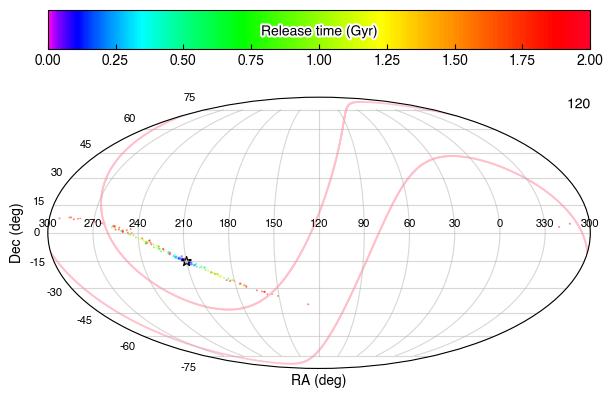

In [357]:

t_tot = 2 * u.Gyr

fig = plt.figure(figsize=(7, 1+4*len(true_stream_id_list)))
gs = gridspec.GridSpec(len(true_stream_id_list)+1, 1, height_ratios=[0.12] + [1] * len(true_stream_id_list))
plt.subplots_adjust(hspace=0.12)
axs = [fig.add_subplot(gs[i+1], projection='mollweide') for i in range(len(true_stream_id_list))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

# cmap = colormaps['gist_rainbow_r']
cmap = power_law_colormap('gist_rainbow_r', 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=2))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

txt = cbar.ax.text(0.5, 0.45, r'Release time (Gyr)', transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])


for key, ax0 in zip(true_stream_id_list, axs):

    mockstream = ds[key]
    
    cmap = power_law_colormap('gist_rainbow_r', 0.5)

    x = np.remainder(120-mockstream.ra, 360)
    x[x>180] -= 360
    x *= np.pi/180
    x_prog = np.remainder(120-mockstream.c_prog.ra.to_value('deg'), 360)
    x_prog -= 360 if x_prog>180 else 0
    x_prog *= np.pi/180
    
    y = mockstream.dec * np.pi/180
    y_prog = mockstream.c_prog.dec * np.pi/180

    mask = -mockstream.release_time*0.978 < t_tot.to_value('Gyr')
    ax0.scatter(x[mask], y[mask], s=2, alpha=0.5, c=-mockstream.release_time[mask]*0.978, ec='None', cmap=cmap, vmin=0, vmax=t_tot.to_value('Gyr'))
    ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)

    txt = ax0.text(1, 1, r'%d'%key, transform=ax0.transAxes, va='top', ha='right')
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

    for nsample, bvalue in zip([1000,1000], [-20,20]):
        l = np.linspace(0,360,nsample)
        b = np.full_like(l, fill_value=bvalue)
        gp = coord.SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').transform_to(coord.ICRS)
        x = np.remainder(120-gp.ra.to_value('deg'), 360)
        x[x>180] -= 360
        x *= np.pi/180
        y = gp.dec.to_value('deg') * np.pi/180
        ax0.scatter(x, y, fc='pink', ec='None', s=2)

    ax0.set_xlabel(r'RA (deg)')
    ax0.set_ylabel(r'Dec (deg)')
    ax0.grid(True, alpha=0.5)
    ax0.set_xticks(np.array([-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180])*np.pi/180,
        [r'300',r'270',r'240',r'210',r'180',r'150',r'120',r'90',r'60',r'30',r'0',r'330',r'300'], fontsize=8)
    ax0.set_yticks(np.array([-75,-60,-45,-30,-15,0,15,30,45,60,75])*np.pi/180,
        [r'-75',r'-60',r'-45',r'-30',r'-15',r'0',r'15',r'30',r'45',r'60',r'75'], fontsize=8)

## Generate mock stream

In [358]:
# load Colin's potential
pot_agama = agama.Potential("../data/pot_523889_snap_99.ini")

In [359]:
# generate mock streams

t_tot = 2000 * u.Myr
dt = 2 * u.Myr
nhalf_per_dt = 1
release_type = 'uniform'
# release_type = 'peri_only'
# release_type = 'gaussian_at_peri'
fwidth = 0.2

n_steps = (t_tot/dt).value.astype(int)
nhalf = n_steps * nhalf_per_dt
assert nhalf % n_steps == 0

mockstreams = {}
T_dict = {}

# for key in ['Pal_5']:
for key in true_stream_id_list:
    stream = ds[key]
    
    gc_mass = 10**stream.prog['logm']
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
        assert np.sum(nhalf_release) == nhalf
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
        assert np.sum(nhalf_release) == nhalf
    elif release_type == 'gaussian_at_peri':
        # release particles as Gaussian distribution around pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_list = np.full_like(peris, fill_value=nhalf_per_release)
        nhalf_list[0] = nhalf - np.sum(nhalf_list[1:])
        width = fwidth * (peris[1] - peris[0])
        nhalf_release = np.zeros(n_steps)
        for peri in peris:
            nhalf_release += np.exp(-0.5*(np.arange(n_steps)-peri)**2/width**2)
        nhalf_release *= nhalf/np.sum(nhalf_release)
        nhalf_release = np.round(nhalf_release).astype(int)
    else:
        raise Exception('unknown release_type')
    
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())
    
    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)

    mockstream.calc_mat_prog()
    mockstream.construct_greatcircle()
    mockstream.construct_greatcircle_coord()
    ds[key].construct_greatcircle_coord(GreatCircle=mockstream.GreatCircle)
    mockstream.set_release_time(time_stream)
    mockstreams[key] = mockstream

1998 orbits complete (11.96 orbits/s)


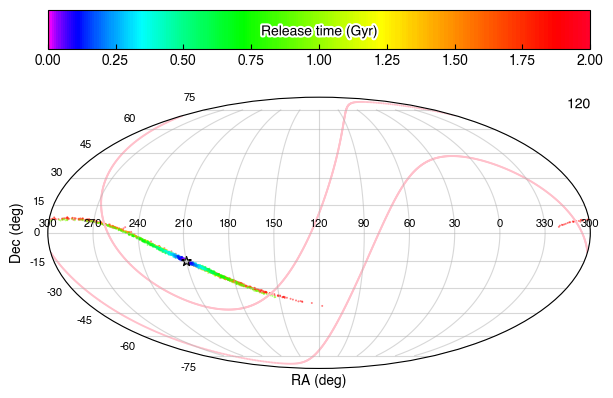

In [360]:
fig = plt.figure(figsize=(7, 1+4*len(true_stream_id_list)))
gs = gridspec.GridSpec(len(true_stream_id_list)+1, 1, height_ratios=[0.12] + [1] * len(true_stream_id_list))
plt.subplots_adjust(hspace=0.12)
axs = [fig.add_subplot(gs[i+1], projection='mollweide') for i in range(len(true_stream_id_list))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

# cmap = colormaps['gist_rainbow_r']
cmap = power_law_colormap('gist_rainbow_r', 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

txt = cbar.ax.text(0.5, 0.45, r'Release time (Gyr)', transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])


for key, ax0 in zip(true_stream_id_list, axs):

    mockstream = mockstreams[key]
    
    cmap = power_law_colormap('gist_rainbow_r', 0.5)

    x = np.remainder(120-mockstream.ra, 360)
    x[x>180] -= 360
    x *= np.pi/180
    x_prog = np.remainder(120-mockstream.c_prog.ra.to_value('deg'), 360)
    x_prog -= 360 if x_prog>180 else 0
    x_prog *= np.pi/180
    
    y = mockstream.dec * np.pi/180
    y_prog = mockstream.c_prog.dec * np.pi/180
    
    ax0.scatter(x, y, s=2, alpha=0.5, c=-mockstream.release_time*0.978, ec='None', cmap=cmap, vmin=0, vmax=t_tot.to_value('Gyr'))
    ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)

    txt = ax0.text(1, 1, r'%d'%key, transform=ax0.transAxes, va='top', ha='right')
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

    for nsample, bvalue in zip([1000,1000], [-20,20]):
        l = np.linspace(0,360,nsample)
        b = np.full_like(l, fill_value=bvalue)
        gp = coord.SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').transform_to(coord.ICRS)
        x = np.remainder(120-gp.ra.to_value('deg'), 360)
        x[x>180] -= 360
        x *= np.pi/180
        y = gp.dec.to_value('deg') * np.pi/180
        ax0.scatter(x, y, fc='pink', ec='None', s=2)

    ax0.set_xlabel(r'RA (deg)')
    ax0.set_ylabel(r'Dec (deg)')
    ax0.grid(True, alpha=0.5)
    ax0.set_xticks(np.array([-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180])*np.pi/180,
        [r'300',r'270',r'240',r'210',r'180',r'150',r'120',r'90',r'60',r'30',r'0',r'330',r'300'], fontsize=8)
    ax0.set_yticks(np.array([-75,-60,-45,-30,-15,0,15,30,45,60,75])*np.pi/180,
        [r'-75',r'-60',r'-45',r'-30',r'-15',r'0',r'15',r'30',r'45',r'60',r'75'], fontsize=8)

## Set key for analysis

In [362]:
key = 120

## Make KDE

In [363]:
# from scipy.spatial.distance import pdist

def epanechnikov(u):
    k = 0.75*(1.-u**2)
    k[k<0] = 0
    return k
    
def gaussian(u):
    return 0.3989422804014327 * np.exp(-0.5*u**2)

def kde(Xdata, Xgrid, h, kernel=gaussian, proj_axes=[]):
    non_proj_axes = np.ones(Xdata.shape[1], dtype=bool)
    non_proj_axes[proj_axes] = False
    dist = np.sqrt(np.sum(((Xgrid[:,non_proj_axes]-Xdata[:,non_proj_axes][:,np.newaxis])/h[:,non_proj_axes][:,np.newaxis])**2, axis=2))
    k = np.sum(kernel(dist) / np.prod(h[:,non_proj_axes],axis=1)[:,np.newaxis], axis=0)
    # k_norm = np.sum(kernel(dist))
    return k/len(Xdata)

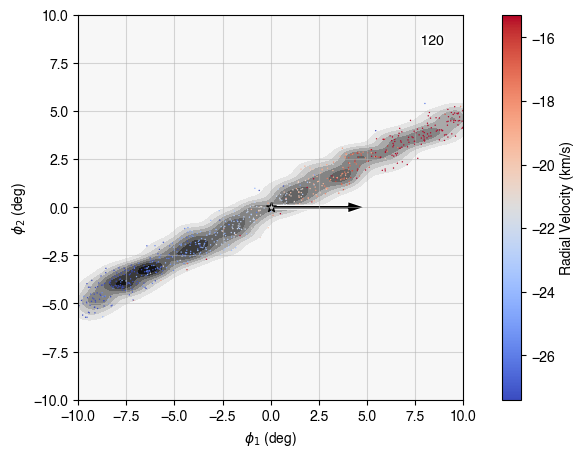

In [364]:
# in great circle frame

xlim = (-10, 10)
ylim = (-10, 10)

fig, ax0 = plt.subplots(1, 1, figsize=(10,5))

mockstream = mockstreams[key]

# cmap = power_law_colormap('gist_rainbow_r', 0.5)

x = mockstream.phi1
x_prog = mockstream.c_prog_GreatCircle.phi1.to_value('deg')

y = mockstream.phi2
y_prog = mockstream.c_prog_GreatCircle.phi2.to_value('deg')

mask_vr = (mockstream.release_time > -6)
mask_vr &= ((x > xlim[0]) & (x < xlim[1]) & (y > ylim[0]) & (y < ylim[1]))
# mask_vr &= ((mockstream.vr > -280) & (mockstream.vr < -200))
# mask_vr &= ((np.abs(mockstream.mu_ra--3.138) < 1) & (np.abs(mockstream.mu_dec--2.572) < 1))
# mask_vr &= ((np.abs(mockstream.mu_ra--3.138) < 1) & (np.abs(mockstream.mu_dec--2.572+mockstream.mu_ra--3.138) < 1))

# make KDE
x_data, y_data, vrad_data, mu_x, mu_y = (x[mask_vr], y[mask_vr], mockstream.vr[mask_vr], 
    mockstream.c_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')[mask_vr], mockstream.c_GreatCircle.pm_phi2.to_value('mas/yr')[mask_vr])
Xdata = np.c_[x_data, y_data, vrad_data, mu_x, mu_y]
# hdata = np.c_[np.full_like(x_data, fill_value=1), np.full_like(x_data, fill_value=1), np.full_like(x_data, fill_value=2), 
#     np.full_like(x_data, fill_value=0.01), np.full_like(x_data, fill_value=0.01)]
# n_neighbor = 4**5
# hdata = np.c_[get_h(x_data,n_neighbor),get_h(y_data,n_neighbor),get_h(vrad_data,n_neighbor),get_h(mu_ra,n_neighbor),get_h(mu_dec,n_neighbor)]
f_h = 0.1
hdata = np.c_[
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(x_data)])),
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(y_data)])),
    np.full_like(x_data, fill_value=np.max([1, f_h*np.std(vrad_data)])),
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(mu_x)])),
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(mu_y)]))
]
x_grid, y_grid, vrad_grid, mu_x_grid, mu_y_grid = np.meshgrid(np.arange(xlim[0],xlim[1]+0.1,0.2), np.arange(ylim[0],ylim[1]+0.1,0.2), [-244.5], [1.3], [0])
Xgrid = np.c_[x_grid.flatten(), y_grid.flatten(), vrad_grid.flatten(), mu_x_grid.flatten(), mu_y_grid.flatten()]
Ygrid = kde(Xdata, Xgrid, hdata, kernel=gaussian, proj_axes=[2,3,4])
Ygrid = Ygrid.reshape(x_grid.shape)

ax0.contourf(x_grid[:,:,0,0,0], y_grid[:,:,0,0,0], Ygrid[:,:,0,0,0], cmap='Greys')

# make scatter plot
vrlim = (mockstream.c_prog.radial_velocity.to_value('km/s')-1*np.std(mockstream.vr[mask_vr]),
         mockstream.c_prog.radial_velocity.to_value('km/s')+1*np.std(mockstream.vr[mask_vr]))
cs = ax0.scatter(x[mask_vr], y[mask_vr], s=1, alpha=1, c=mockstream.vr[mask_vr], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1])

vx = mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')
vy = mockstream.c_prog_GreatCircle.pm_phi2.to_value('mas/yr')
norm = 0.2*(xlim[1]-xlim[0]) / np.sqrt(vx**2 + vy**2)
ax0.arrow(0,0,norm*vx,norm*vy, width=0.2, fc='k', ec='w')
ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)


txt = ax0.text(0.95, 0.95, r'%s'%key, transform=ax0.transAxes, va='top', ha='right')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r'Radial Velocity (km/s)')

ax0.set_xlabel(r'$\phi_1$ (deg)')
ax0.set_ylabel(r'$\phi_2$ (deg)')
ax0.set_xlim(xlim[0],xlim[1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

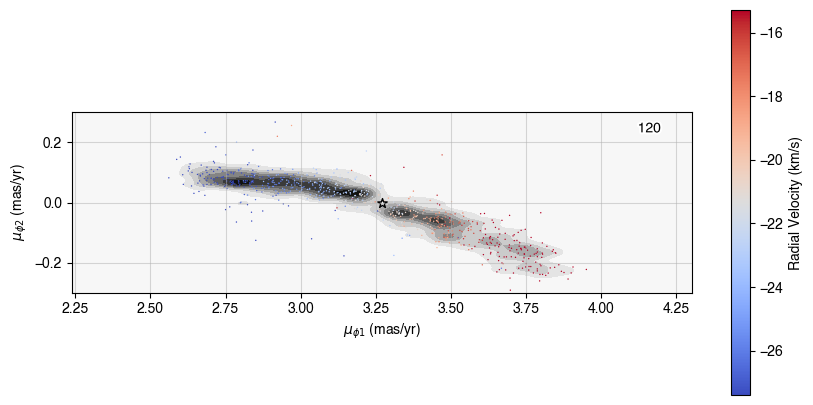

In [365]:
xlim = (mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')-3*np.std(mu_x),
        mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')+3*np.std(mu_x))
ylim = (-3*np.std(mu_y),+3*np.std(mu_y))

fig, ax0 = plt.subplots(1, 1, figsize=(10,5))

xpm_grid, ypm_grid, vrad_grid, mu_x_grid, mu_y_grid = np.meshgrid([0], [0], [-55], np.linspace(xlim[0],xlim[1],100+1), np.linspace(ylim[0],ylim[1],100+1))
Xgrid = np.c_[x_grid.flatten(), y_grid.flatten(), vrad_grid.flatten(), mu_x_grid.flatten(), mu_y_grid.flatten()]
Ypmgrid = kde(Xdata, Xgrid, hdata, kernel=gaussian, proj_axes=[0,1,2])
Ypmgrid = Ypmgrid.reshape(xpm_grid.shape)

ax0.contourf(mu_x_grid[0,0,0,:,:], mu_y_grid[0,0,0,:,:], Ypmgrid[0,0,0,:,:], cmap='Greys')

# make scatter plot

x = mu_x
x_prog = mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')
y = mu_y
y_prog = mockstream.c_prog_GreatCircle.pm_phi2.to_value('mas/yr')

cs = ax0.scatter(x, y, s=1, alpha=1, c=mockstream.vr[mask_vr], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1])
ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)

txt = ax0.text(0.95, 0.95, r'%s'%key, transform=ax0.transAxes, va='top', ha='right')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r'Radial Velocity (km/s)')

ax0.set_xlabel(r'$\mu_{\phi1}$ (mas/yr)')
ax0.set_ylabel(r'$\mu_{\phi2}$ (mas/yr)')
ax0.set_xlim(xlim[0],xlim[1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

## Mock observation

In [366]:
xlim = (-10, 10)
ylim = (-10, 10)

mockstream = ds[key]

mask = ((mockstream.phi1 > xlim[0]) & (mockstream.phi1 < xlim[1]))
mask &= ((mockstream.phi2 > ylim[0]) & (mockstream.phi2 < ylim[1]))
mask &= (mockstream.release_time > -2)
phi1_obs = mockstream.phi1[mask]
phi2_obs = mockstream.phi2[mask]
mu_phi1_obs = mockstream.c_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')[mask]
mu_phi2_obs = mockstream.c_GreatCircle.pm_phi2.to_value('mas/yr')[mask]

n_true = len(phi1_obs)

# make background
rng = np.random.default_rng(0)
n_bg = int(1e5)
phi1_obs = np.r_[phi1_obs, rng.random(n_bg)*(xlim[1]-xlim[0])+xlim[0]]
phi2_obs = np.r_[phi2_obs, rng.random(n_bg)*(ylim[1]-ylim[0])+ylim[0]]
mu_phi1_obs = np.r_[mu_phi1_obs, rng.normal(0, 10, size=n_bg)]
mu_phi2_obs = np.r_[mu_phi2_obs, rng.normal(0, 10, size=n_bg)]

### compute likelihood

In [367]:
def gaussian_func(x, mu, sig):
    return np.exp(-0.5*(x-mu)**2/sig**2) / np.sqrt(2*np.pi*sig**2)

In [368]:
# compute probabilities

# prob_bg = \
#     1 / (xlim[1]-xlim[0]) * \
#     1 / (ylim[1]-ylim[0]) * \
#     np.interp(vr_obs, vr_grid, vr_prob) * \
#     np.interp(mu_phi1_obs, mu_phi1_grid, mu_phi1_prob) * \
#     np.interp(mu_phi2_obs, mu_phi2_grid, mu_phi2_prob) * \
#     metal_interp(metal_obs)

prob_bg = \
    1 / (xlim[1]-xlim[0]) * \
    1 / (ylim[1]-ylim[0]) * \
    gaussian_func(mu_phi1_obs, 0, 10) * \
    gaussian_func(mu_phi2_obs, 0, 10)

Xobs = np.c_[phi1_obs, phi2_obs, np.full_like(phi1_obs, fill_value=np.nan), mu_phi1_obs, mu_phi2_obs]
# prob_stream = \
#     kde(Xdata, Xobs, hdata, kernel=gaussian, proj_axes=2) * \
#     metal_gc_interp(metal_obs)

prob_stream = \
    kde(Xdata, Xobs, hdata, kernel=gaussian, proj_axes=[2])

peak at 7.24e-04


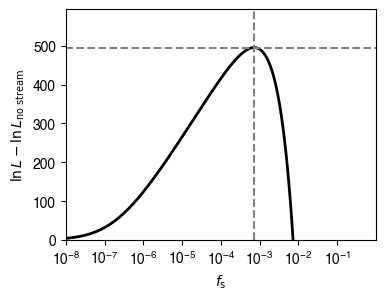

In [369]:
# compute likelihood

frac_list = 10.**np.arange(-10,0+0.001,0.02)
# frac_list = np.arange(0.0,0.1,0.001)
lnL_list = []

lnL_base = np.sum(np.log(prob_bg))

for frac in frac_list:
    lnL_list.append(np.sum(np.log(prob_stream*frac + prob_bg*(1-frac))))

lnL_list = np.array(lnL_list)

fig, ax0 = plt.subplots(1, 1, figsize=(4,3))

ax0.plot(frac_list, lnL_list-lnL_base, c='k', lw=2)
ax0.hlines(np.max(lnL_list)-lnL_base, 1e-10, 1e0, color='gray', ls='--')
ax0.vlines(frac_list[np.argmax(lnL_list)], 0, 1e9, color='gray', ls='--')

print('peak at %.2e'%frac_list[np.argmax(lnL_list)])

ax0.set_xscale('log')
# ax0.set_xscale('log')
ax0.set_xlabel(r'$f_{\rm s}$')
ax0.set_ylabel(r'$\ln L-\ln L_{\rm no\ stream}$')
ax0.set_xlim(1e-8, 1e0)
ax0.set_ylim(0, 1.2*(np.max(lnL_list)-lnL_base))
ax0.set_xticks(10**np.arange(-8,-1+0.1,1))
# ax0.grid(True, alpha=0.5)

plt.show()

number of stream stars: 73, number of all stars: 100070


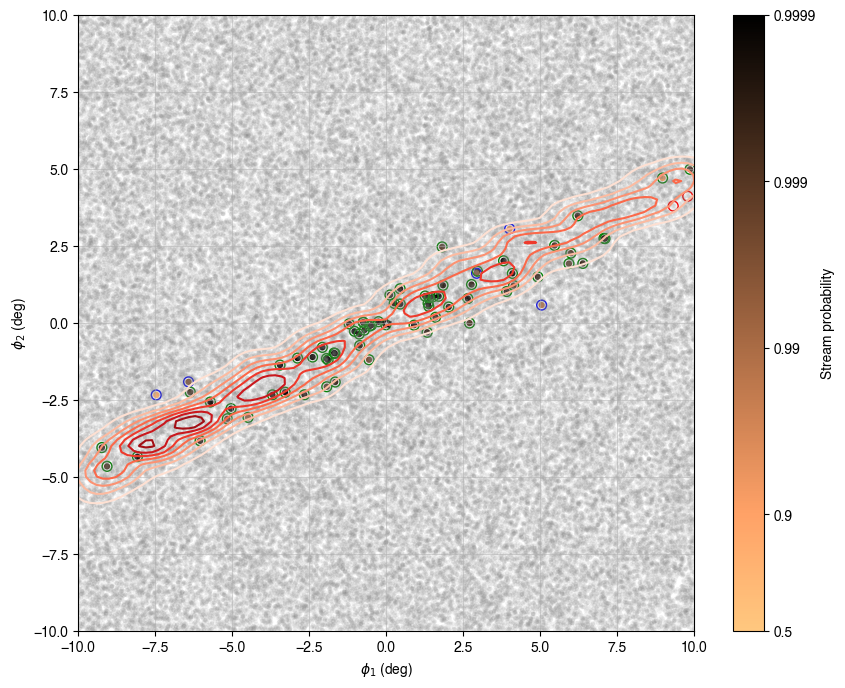

In [370]:
fig, ax0 = plt.subplots(1, 1, figsize=(10,8))

frac = frac_list[np.argmax(lnL_list)]

prob = frac*prob_stream / (frac*prob_stream + (1-frac)*prob_bg)

mask_select = prob > 0.5

print('number of stream stars: %d, number of all stars: %d'%(len(phi1_obs[mask_select]),len(phi1_obs)))

ax0.contour(x_grid[:,:,0,0,0], y_grid[:,:,0,0,0], Ygrid[:,:,0,0,0], cmap='Reds')

# cs = ax0.scatter(phi1_obs[mask_select], phi2_obs[mask_select], c=vr_obs[mask_select], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1], s=10)
# cbar = fig.colorbar(cs)
# cbar.ax.set_ylabel(r'Radial velocity (km/s)')

cs = ax0.scatter(phi1_obs[mask_select], phi2_obs[mask_select], c=np.log10(1-prob[mask_select]), ec='None', cmap='copper', vmin=-4, vmax=np.log10(0.5), s=20)
cbar = fig.colorbar(cs, ticks=[-4,-3,-2,-1,np.log10(0.5)])
cbar.ax.set_yticklabels(['0.9999', '0.999', '0.99', '0.9', '0.5'])
cbar.ax.set_ylabel(r'Stream probability')
cbar.ax.set_ylim(np.log10(0.5),-4)

# cs = ax0.scatter(phi1_obs[mask_select], phi2_obs[mask_select], c=mu_phi2_obs[mask_select], ec='k', cmap='coolwarm', s=40, vmin=-10, vmax=10)
# cbar = fig.colorbar(cs)

cs = ax0.scatter(phi1_obs[n_true:][mask_select[n_true:]], phi2_obs[n_true:][mask_select[n_true:]], ec='b', fc='None', s=50, lw=1)

cs = ax0.scatter(phi1_obs[:n_true][~mask_select[:n_true]], phi2_obs[:n_true][~mask_select[:n_true]], ec='r', fc='None', s=50, lw=1)
cs = ax0.scatter(phi1_obs[:n_true][mask_select[:n_true]], phi2_obs[:n_true][mask_select[:n_true]], ec='g', fc='None', s=50, lw=1)

# ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)
ax0.scatter(0, 0, s=50, marker='*', fc='w', ec='k', lw=1)
ax0.scatter(phi1_obs, phi2_obs, fc='gray', ec='None', s=10, alpha=0.1, zorder=1)
# ax0.scatter(phi1_obs, phi2_obs, c=mu_phi2_obs, cmap='coolwarm', ec='None', s=40, alpha=0.4, zorder=1, vmin=-10, vmax=10)

ax0.set_xlabel(r'$\phi_1$ (deg)')
ax0.set_ylabel(r'$\phi_2$ (deg)')
ax0.set_xlim(xlim[0], xlim[1])
ax0.set_ylim(ylim[0], ylim[1])
ax0.set_ylim(-10, 10)
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

In [371]:

mockstream = ds[key]

mask = ((mockstream.phi1 > xlim[0]) & (mockstream.phi1 < xlim[1]))
mask &= ((mockstream.phi2 > ylim[0]) & (mockstream.phi2 < ylim[1]))
mask &= (mockstream.release_time > -2)

In [372]:
(mockstream.release_time[mask]>-tcut).shape

(70,)

In [374]:
tcut = 2
np.sum(mask_select[:n_true][mockstream.release_time[mask]>-tcut]) / np.sum(mockstream.release_time[mask]>-tcut)

0.9714285714285714

## Hey, it's the last line! Stop pressing `Shift + Enter`